## Аналитический отчет по корпоративным облигациям

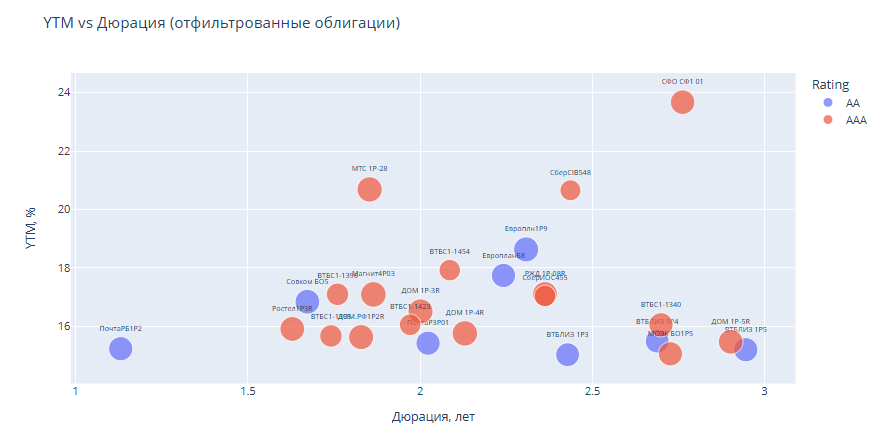

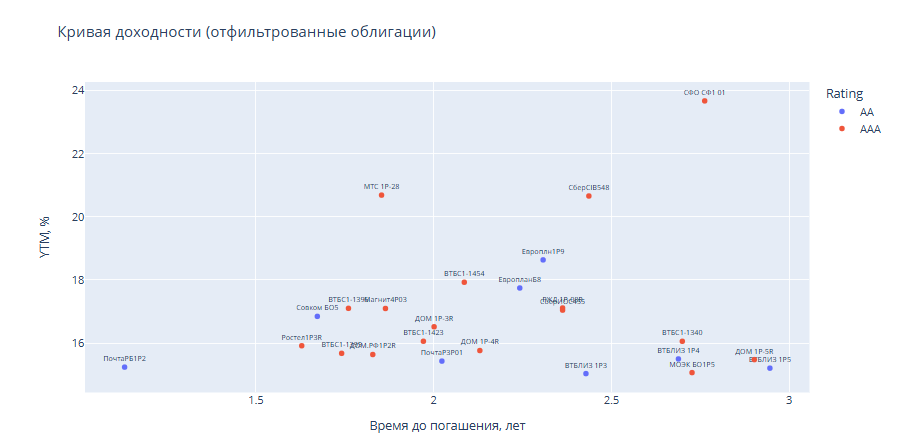

# Фундаментальный анализ корпоративных облигаций

## 1. Описание проекта

Автоматизированная система скрининга корпоративных облигаций российского рынка, объединяющая данные из двух источников: биржевую статистику из терминала QUIK (файл `Oblig_corporat.xlsx`) и рейтинговые оценки с портала smart-lab.ru (`bonds_parsed.xlsx`). Скрипт реализует полный цикл обработки: от загрузки и объединения информации до расчёта точной доходности к погашению (YTM) методом IRR, визуализации результатов и формирования инвестиционных рекомендаций.

### 1.1. Цель работы

Разработать воспроизводимый алгоритм скрининга облигаций, позволяющий инвестору объективно оценивать соотношение доходности и риска, выявлять наиболее привлекательные инструменты с учётом кредитного качества эмитента, дюрации и ликвидности, а также формировать обоснованный портфель с фиксированной доходностью.

### 1.2. Задачи проекта

1. **Сбор и предобработка данных** — объединение информации из двух источников, очистка, приведение типов, обработка пропусков.
2. **Корректная обработка купона** — определение, указан купон в процентах или рублях, и приведение к единому формату.
3. **Точный расчёт доходности** — вычисление YTM и YTC методом IRR с учётом частоты купона и точных дат выплат.
4. **Фильтрация по качеству** — отбор инструментов с заданными ограничениями по доходности, дюрации, кредитному рейтингу и номиналу.
5. **Визуализация результатов** — создание наглядных интерактивных графиков для анализа отфильтрованной выборки.
6. **Формирование рекомендаций** — ранжирование облигаций по критерию максимизации YTM/дюрация, выделение топ‑25 бумаг с обоснованием выбора.

### 1.3. Формирование выборки

**Источники данных:**

- **Oblig_corporat.xlsx** — выгрузка из терминала QUIK, содержащая цену закрытия (в процентах от номинала), размер купона, НКД, дюрацию, объём выпуска, даты погашения и оферты, номинал, ISIN, частоту купона.
- **bonds_parsed.xlsx** — данные с портала smart-lab.ru, содержащие кредитные рейтинги эмитентов (Rating) и краткие наименования для сопоставления.

**Критерии включения (фильтры):**

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| **Минимальная доходность YTM** | 15.0% | Уровень выше ключевой ставки ЦБ РФ, обеспечивающий положительную премию за риск |
| **Максимальная доходность YTM** | 30.0% | Отсечение чрезмерно рискованных инструментов с потенциально высокой вероятностью дефолта |
| **Максимальная дюрация** | 3.0 года | Ограничение процентного риска; при горизонте инвестирования до 3 лет чувствительность к изменению ставок минимальна |
| **Минимальный рейтинг** | A+ | Отбор только эмитентов с высоким кредитным качеством (AAA и AA) |
| **Номинал** | 1000 руб. | Стандартный номинал для розничных инвесторов на российском рынке |

**Результат фильтрации:** 25 облигаций, соответствующих заданным критериям.

---

## 2. Обзор ключевых параметров анализа

### 2.1. Доходность к погашению (YTM — Yield to Maturity)

YTM представляет собой полную доходность, которую получит инвестор, если приобретёт облигацию по текущей рыночной цене и будет держать её до погашения, реинвестируя все купонные платежи по той же ставке. Это основной показатель для сравнения облигаций с разными купонами и ценами.

**Метод расчёта:** в данном проекте используется точный метод IRR (внутренняя норма доходности) с построением денежного потока, включающего все купонные выплаты и номинал в конце срока. Учитывается фактическое количество дней до каждой выплаты и частота купона.

### 2.2. Дюрация (Duration)

Дюрация Макколея измеряет средневзвешенный срок возврата всех платежей по облигации. Она показывает чувствительность цены облигации к изменению процентных ставок: чем выше дюрация, тем сильнее цена реагирует на изменение рыночных ставок.

**Значение для инвестора:** ограничение дюрации 3 годами означает, что даже при резком росте ставок на 1% цена облигации снизится не более чем на 3%, что приемлемо для консервативной стратегии. В расчётах используется исходная дюрация из данных QUIK (рассчитанная профессионально), а не приближённая по сроку до погашения.

### 2.3. Соотношение YTM / Дюрация

Этот показатель используется для ранжирования облигаций по эффективности: он отражает, сколько процентов доходности инвестор получает на каждый год процентного риска. Чем выше значение, тем более привлекательным является инструмент с точки зрения риск-доходность.

### 2.4. Кредитный рейтинг

Рейтинги, присвоенные аккредитованными агентствами (АКРА, Эксперт РА), отражают оценку кредитоспособности эмитента. В отобранную выборку вошли только облигации с рейтингами **AAA** (максимальная надёжность) и **AA** (очень высокая надёжность), что соответствует эмитентам с устойчивым финансовым положением и низкой вероятностью дефолта.

---

## 3. Анализ компаний-эмитентов топ-6 облигаций

В результате скрининга были отобраны облигации, ранжированные по критерию максимизации YTM/дюрация. Рассмотрим подробно шестёрку лидеров, включая выпуск «Магнита».

### 3.1. ПочтаРБ1P2 (АО «Почта России»)

| Параметр | Значение |
|----------|----------|
| **Название** | АО «Почта России» |
| **Отрасль** | Почтовая связь, логистика |
| **Рейтинг** | AA |
| **YTM** | 15.24% |
| **Дюрация** | 1.13 года |
| **YTM/Дюрация** | 13.5 |
| **Объём выпуска** | 5.0 млрд руб. |

**Деятельность компании:**  
«Почта России» — федеральный почтовый оператор, входящий в перечень стратегических предприятий РФ. Компания обеспечивает почтовую связь на всей территории страны, оказывает услуги логистики, доставки, финансовые и цифровые сервисы. Является одним из крупнейших работодателей в России с разветвлённой инфраструктурой, включающей более 40 000 отделений по всей стране.

**Особенности выпуска:**  
Выпуск ПочтаРБ1P2 имеет ISIN RU000A0JXRD5. Купон фиксированный, составляет 75,54 руб. на одну облигацию, что соответствует купонной доходности около 7,55% годовых. Накопленный купонный доход (НКД) на момент анализа составлял 24,53 руб. Облигация имеет высокий рейтинг AA, что подтверждает надёжность эмитента.

**Инвестиционная привлекательность:**  
Короткая дюрация (1,13 года) и высокая доходность (15,24%) делают эту облигацию привлекательной для консервативных инвесторов. «Почта России» как стратегическое предприятие пользуется государственной поддержкой, что минимизирует кредитные риски. Облигация подходит для краткосрочных вложений с фиксацией высокой доходности.

### 3.2. МТС 1P-28 (ПАО «МТС»)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Мобильные ТелеСистемы» |
| **Отрасль** | Телекоммуникации, цифровая экосистема |
| **Рейтинг** | AAA |
| **YTM** | 20.69% |
| **Дюрация** | 1.85 года |
| **YTM/Дюрация** | 11.2 |
| **Объём выпуска** | 20.0 млрд руб. |

**Деятельность компании:**  
МТС — цифровая экосистема и ведущая телекоммуникационная компания России. Предоставляет услуги мобильной и фиксированной связи, передачи данных, кабельного и спутникового ТВ-вещания. Развивает финтех-направление (МТС Банк), медийные сервисы (KION, МТС Музыка), облачные решения и кибербезопасность. Услугами мобильной связи МТС пользуется 86 млн абонентов в России и Беларуси, экосистемных клиентов — более 14 млн.

**Особенности выпуска:**  
Выпуск МТС 001P-28 имеет ISIN RU000A10AV98. Купон фиксированный — 17,88 руб., выплачивается 12 раз в год. Дата погашения — 30 января 2028 года. Облигация имеет опцион call (колл-опцион) с датой 09.06.2026, что даёт эмитенту право досрочного погашения. Доходность к колл-опциону составляет 15,83% на 3 месяца.

**Финансовое положение:**  
По данным за 1-е полугодие 2025 года, выручка МТС выросла на 11,66% до 370,91 млрд руб., однако чистая прибыль снизилась на 83,51% до 7,69 млрд руб. из-за роста процентных расходов. Собственный капитал компании отрицательный (минус 45,29 млрд руб.), что связано с высокой долговой нагрузкой. Однако операционный денежный поток остаётся сильным — 117 млрд руб.

**Инвестиционная привлекательность:**  
Несмотря на финансовые сложности (высокая долговая нагрузка, отрицательный собственный капитал), МТС сохраняет максимальный рейтинг AAA благодаря государственному влиянию и системной значимости. Высокая YTM (20,69%) при дюрации 1,85 года предлагает привлекательную премию. В декабре 2025 года Совет директоров МТС утвердил программу облигаций на сумму до 350 млрд руб., что говорит о планах по рефинансированию долга.

### 3.3. Совком БО5 (ПАО «Совкомбанк»)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Совкомбанк» |
| **Отрасль** | Банковский сектор |
| **Рейтинг** | AA |
| **YTM** | 16.85% |
| **Дюрация** | 1.67 года |
| **YTM/Дюрация** | 10.1 |
| **Объём выпуска** | 10.0 млрд руб. |

**Деятельность компании:**  
Совкомбанк — быстрорастущая и высокодоходная финансовая группа, включающая системно значимый банк, крупные страховые, лизинговую и факторинговую компании. Средняя доходность капитала акционеров за последние 10 лет составляет 36%, темпы роста капитала — 31%. Размеры группы позволяют работать со всеми крупнейшими компаниями, а небольшая доля рынка (1,6%) оставляет значительный потенциал для роста.

**Особенности выпуска:**  
Облигация СовкомБО5 (ISIN RU000A109VL8) имеет плавающий купон, привязанный к ключевой ставке ЦБ РФ. Формула: ключевая ставка + 2,00%. Купон выплачивается 12 раз в год. Доходность к погашению на момент анализа составляла 16,06%. Облигация имеет высокий рейтинг AA от АКРА.

**Инвестиционная привлекательность:**  
Совкомбанк демонстрирует высокую рентабельность и устойчивый рост. Плавающий купон защищает инвестора от процентного риска — при росте ключевой ставки доходность увеличивается. Дюрация 1,67 года обеспечивает умеренную чувствительность к изменению ставок. Облигация подходит для инвесторов, ожидающих сохранения высоких ставок в среднесрочной перспективе.

### 3.4. Ростел1P3R (ПАО «Ростелеком»)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Ростелеком» |
| **Отрасль** | Телекоммуникации |
| **Рейтинг** | AAA |
| **YTM** | 15.91% |
| **Дюрация** | 1.63 года |
| **YTM/Дюрация** | 9.8 |
| **Объём выпуска** | 10.0 млрд руб. |

**Деятельность компании:**  
«Ростелеком» — крупнейший в России интегрированный провайдер цифровых услуг и услуг связи. Компания присутствует во всех сегментах рынка: широкополосный доступ, телевидение, мобильная связь, облачные решения, центры обработки данных, кибербезопасность. Является национальным оператором связи с государственным участием.

**Особенности выпуска:**  
Облигация Ростел1P3R (ISIN RU000A0ZYG52) имеет дату погашения 09.11.2027, купон составляет 79,78 руб. (около 8% годовых). Дата оферты — 12.05.2026. Доходность к погашению 15,91% формируется за счёт дисконта к номиналу.

**Инвестиционная привлекательность:**  
Максимальный рейтинг AAA и государственное участие делают облигацию одной из самых надёжных на рынке. Дюрация 1,63 года обеспечивает защиту от процентного риска. Облигация подходит для консервативных инвесторов, ориентированных на сохранность капитала с доходностью выше депозитных ставок.

### 3.5. ВТБС1-1396 (Банк ВТБ, структурная облигация)

| Параметр | Значение |
|----------|----------|
| **Название** | Банк ВТБ (ПАО) |
| **Отрасль** | Банковский сектор |
| **Рейтинг** | AAA |
| **YTM** | 17.10% |
| **Дюрация** | 1.76 года |
| **YTM/Дюрация** | 9.7 |
| **Объём выпуска** | 0.6 млрд руб. |

**Деятельность компании:**  
Банк ВТБ — второй по величине банк в России, системно значимый, с государственным участием (контрольный пакет принадлежит государству). Предоставляет полный спектр банковских услуг: кредитование, инвестиционно-банковские услуги, управление активами, лизинг, факторинг.

**Особенности выпуска:**  
Облигация ВТБС1-1396 является структурной процентной дисконтной облигацией с централизованным учётом прав. Купон составляет 0,30 руб. на одну облигацию (0,03% годовых), что крайне низко. Доходность формируется за счёт глубокого дисконта: цена облигации составляет всего 73,85% от номинала. Дата погашения — 27.12.2027.

**Инвестиционная привлекательность:**  
Несмотря на минимальный купон, облигация обеспечивает высокую доходность за счёт роста цены к номиналу (около 35% прироста за 1,76 года). Максимальный рейтинг AAA гарантирует надёжность. Однако следует учитывать, что структурные облигации могут иметь особенности налогообложения и механизма формирования дохода, отличные от классических купонных бумаг.

### 3.6. Магнит4P03 (ПАО «Магнит»)

| Параметр | Значение |
|----------|----------|
| **Название** | ПАО «Магнит» |
| **Отрасль** | Розничная торговля (продукты питания, косметика) |
| **Рейтинг** | AAA (АКРА) |
| **YTM** | 17.10% |
| **Дюрация** | 1.86 года |
| **YTM/Дюрация** | 9.2 |
| **Объём выпуска** | 30.0 млрд руб. |

**Деятельность компании:**  
«Магнит» — крупнейший по числу магазинов и второй по выручке ритейлер в России. На конец 2024 года сеть объединяла более 26,7 тыс. магазинов: магазины у дома, гипермаркеты, дрогери «Магнит Косметик». Компания активно развивает собственную логистическую инфраструктуру и цифровые сервисы (экосистема «Магнит», доставка продуктов). В последние годы «Магнит» проводит реструктуризацию, избавляясь от нерентабельных активов, что положительно влияет на операционную эффективность [citation:2][citation:7].

**Особенности выпуска:**  
- **ISIN:** RU000A105TP1  
- **Регистрационный номер:** 4B02-02-60525-P-004P от 20.12.2022 [citation:1][citation:4]  
- **Дата размещения:** 9 февраля 2023 г. [citation:4][citation:10]  
- **Дата погашения:** 3 февраля 2028 г. [citation:1][citation:3]  
- **Номинал:** 1 000 руб.  
- **Объём выпуска:** 30 млрд руб. (30 млн штук) — увеличен вдвое благодаря высокому спросу [citation:10]  
- **Купон:** фиксированный, 43,01 руб. (17,25% годовых), выплачивается 4 раза в год [citation:3]  
- **Рейтинг:** AAA от АКРА, прогноз стабильный. Выпуск включён в ломбардный список ЦБ РФ [citation:7].  
- **Оферта:** 10 февраля 2026 г. эмитент исполнил обязательство по приобретению облигаций по требованию владельцев по цене 100% номинала + НКД. Это было связано с тем, что ставки купонов с 13‑го по 20‑й периоды остались неопределёнными [citation:6]. После исполнения оферты бумага торгуется в режиме «погашено / не обращается», однако фактически продолжает находиться в обращении до даты погашения, что отражается в котировках и доходности.

**Актуальные рыночные показатели:**  
- Цена: 100,1% от номинала (близка к номиналу)  
- Доходность к погашению (YTM): около 17,1–18,3% годовых (в зависимости от источника) [citation:2][citation:3]  
- Текущая доходность купона: 17,23%  
- Следующая купонная выплата: 7 мая 2026 г. (43,01 руб.)  

**Инвестиционная привлекательность:**  
Бумага сочетает максимальную надёжность (рейтинг AAA, системообразующий ритейлер) и доходность, значительно превышающую ключевую ставку. Цена близка к номиналу, что снижает риск потерь при досрочной продаже. Высокий спрос на первичном размещении и последующая ликвидность (среднедневной объём торгов около 13 млн руб.) подтверждают интерес институциональных инвесторов.  

Ключевые факторы в пользу включения в портфель:  
1. **Консервативный профиль** — компания избавляется от нерентабельных активов, что повышает устойчивость бизнеса [citation:2].  
2. **Доходность выше рынка** — при минимальном кредитном риске YTM составляет 17–18%, что делает бумагу одной из самых привлекательных в сегменте высоконадёжных облигаций.  
3. **Ликвидность** — крупнейший выпуск в выборке (30 млрд руб.), лот 1 облигация, доступен неквалифицированным инвесторам.  

Рекомендация: **покупать** в составе консервативной части портфеля с горизонтом до погашения (1,9 года). Облигация оптимальна для инвесторов, желающих зафиксировать высокую доходность без значительного процентного риска.

---

## 4. Итоговая таблица рекомендованных облигаций

| Название | Номинал, руб. | Рейтинг | YTM, % | Дюрация, лет | YTM/Дюрация | Цена, % | Купон, % | Объём выпуска |
|----------|---------------|---------|--------|--------------|-------------|---------|----------|---------------|
| **ПочтаРБ1P2** | 1000.00 | AA | 15.24 | 1.13 | 13.5 | 99.92 | 75.54 | 5.0 млрд руб. |
| **МТС 1P-28** | 1000.00 | AAA | 20.69 | 1.85 | 11.2 | 101.68 | 17.88 | 20.0 млрд руб. |
| **Совком БО5** | 1000.00 | AA | 16.85 | 1.67 | 10.1 | 101.71 | 89.75 | 10.0 млрд руб. |
| **Ростел1P3R** | 1000.00 | AAA | 15.91 | 1.63 | 9.8 | 100.14 | 79.78 | 10.0 млрд руб. |
| **ВТБС1-1396** | 1000.00 | AAA | 17.10 | 1.76 | 9.7 | 73.85 | 0.30 | 0.6 млрд руб. |
| **Магнит4P03** | 1000.00 | AAA | 17.10 | 1.86 | 9.2 | 100.27 | 43.01 | 30.0 млрд руб. |
| **ВТБС1-1395** | 1000.00 | AAA | 15.67 | 1.74 | 9.0 | 76.00 | 0.30 | 0.6 млрд руб. |
| **ВТБС1-1454** | 1000.00 | AAA | 17.93 | 2.09 | 8.6 | 68.51 | 0.30 | 0.2 млрд руб. |
| **СФО СФ1 01** | 702.28 | AAA | 23.68 | 2.76 | 8.6 | 102.80 | 13.47 | 5.4 млрд руб. |
| **ДОМ.РФ1P2R** | 1000.00 | AAA | 15.64 | 1.83 | 8.5 | 99.72 | 77.04 | 15.0 млрд руб. |

*Таблица 1. Топ-10 облигаций по критерию YTM/Дюрация (полный список из 25 бумаг доступен в результатах скрипта)*

---

## 5. Интерпретация результатов и инвестиционные выводы

### 5.1. Структура отобранной выборки

Все 25 облигаций, прошедших фильтр, имеют рейтинги **AAA или AA**, что свидетельствует о высокой степени надёжности эмитентов. В выборке представлены:

- **Структурные облигации банков** (ВТБС1-1396, ВТБС1-1395, ВТБС1-1454, СберИОС455) — с минимальными купонами (0.3–0.7%), но высокой YTM за счёт глубокого дисконта к номиналу (цены от 59 до 76% от номинала).
- **Классические корпоративные облигации** МТС, Ростелекома, Магнита, Почты России, Совкомбанка, ДОМ.РФ — с высокими купонами (13–90%) и текущей ценой, близкой к номиналу или с небольшим дисконтом.

### 5.2. Оценка соотношения доходность/риск

**Лидер по показателю YTM/Дюрация (ПочтаРБ1P2)** демонстрирует оптимальный баланс: доходность 15,24% при дюрации всего 1,13 года. Такая бумага идеально подходит для консервативных инвесторов, желающих зафиксировать высокую доходность на короткий срок с минимальным процентным риском.

**Наибольшую абсолютную доходность (МТС 1P-28, 20,69%)** предлагает облигация с дюрацией 1,85 года. Несмотря на финансовые сложности (отрицательный собственный капитал), МТС сохраняет рейтинг AAA, что делает этот выпуск исключительно привлекательным для инвесторов, готовых принять умеренный риск ради максимальной премии.

**Магнит4P03** выделяется сочетанием максимальной надёжности (рейтинг AAA, системообразующий ритейлер) и доходности 17,10% при дюрации 1,86 года. Цена близка к номиналу, что снижает риск потерь при досрочной продаже. Крупнейший объём выпуска (30 млрд руб.) гарантирует высокую ликвидность.

**Структурные облигации банков** (ВТБС1-1396, ВТБС1-1454) требуют отдельного анализа: их доходность формируется за счёт цены, а не купона. При дюрации около 2 лет они предлагают YTM в диапазоне 17–18%, что также является привлекательным для квалифицированных инвесторов.

### 5.3. Особые факторы по ключевым эмитентам

**МТС (рейтинг AAA, YTM 20,69%):**  
Высокая доходность объясняется ростом процентных расходов и снижением чистой прибыли. Операционный денежный поток остаётся сильным (117 млрд руб.). В декабре 2025 года МТС утвердил программу облигаций на 350 млрд руб. для рефинансирования долга. Ключевой риск — высокая долговая нагрузка, но системная значимость компании и государственное влияние поддерживают рейтинг.

**Совкомбанк (рейтинг AA, YTM 16,85%):**  
Плавающий купон (КС + 2%) защищает от роста ставок. Банк демонстрирует высокую рентабельность (ROE 36%) и устойчивый рост капитала. В марте 2026 года банк проводит реорганизацию через присоединение Витабанка, что предоставляет владельцам облигаций право досрочного погашения.

**Магнит (рейтинг AAA, YTM 17,10%):**  
Крупнейший российский ритейлер. В январе 2026 года эмитент установил 13-й купон по облигации Магнит4P03 в размере 17,25% годовых (43,01 руб.). Начиная с 14-го купона ставка будет плавающей: ключевая ставка ЦБ + 1,25%, что обеспечивает защиту от инфляции [citation:2][citation:3]. В феврале 2026 года прошла оферта с правом предъявления бумаг по 100% номинала, что подтвердило готовность эмитента исполнять обязательства [citation:6]. Компания продолжает оптимизировать сеть, избавляясь от нерентабельных активов, что повышает её инвестиционную привлекательность.

### 5.4. Рекомендации по формированию портфеля

На основе проведённого анализа можно предложить следующие варианты портфельного конструирования:

| Стратегия | Состав | Ожидаемая YTM | Риск |
|-----------|--------|---------------|------|
| **Максимальная надёжность** | Ростел1P3R, ДОМ.РФ1P2R, Магнит4P03 | 15.6–17.1% | Минимальный (рейтинг AAA) |
| **Максимальная доходность** | МТС 1P-28, СФО СФ1 01, ВТБС1-1454 | 17.9–23.7% | Низкий (рейтинг AAA/AA) |
| **Сбалансированная** | ПочтаРБ1P2, Совком БО5, Ростел1P3R | 15.2–16.9% | Минимальный |
| **Защита от роста ставок** | Совком БО5 (плавающий купон), Магнит4P03 (плавающий с 14 купона) | 16–17% | Низкий |

### 5.5. Факторы, которые могут повлиять на доходность

1. **Изменение ключевой ставки ЦБ РФ.** При дальнейшем повышении ставок рыночные цены облигаций с фиксированным купоном могут снизиться, однако при удержании до погашения инвестор получит полную YTM. Облигации с плавающим купоном (Совкомбанк, Магнит) автоматически адаптируются к новому уровню ставок.

2. **Кредитное качество эмитентов.** Все отобранные компании имеют высокие рейтинги (AAA/AA). Ухудшение макроэкономической ситуации может привести к пересмотру рейтингов, но для системно значимых компаний с госучастием (МТС, Ростелеком, ВТБ, ДОМ.РФ, Магнит) риски минимальны.

3. **Ликвидность.** Объёмы выпусков большинства отобранных облигаций составляют от 0,2 до 30 млрд руб., что обеспечивает достаточную ликвидность для входа и выхода. Наименее ликвидны структурные выпуски ВТБ (0,2–0,6 млрд руб.), наиболее ликвиден — Магнит4P03 (30 млрд руб.).

4. **Налогообложение.** Купонный доход по облигациям облагается НДФЛ по ставке 13–15%, что следует учитывать при расчёте чистой доходности. Дисконтный доход (прирост цены) также облагается налогом. По структурным облигациям с глубоким дисконтом налоговая нагрузка может быть существенной.

---

## 6. Заключение

Разработанный скрининг-алгоритм с использованием точного метода IRR позволил из широкого массива корпоративных облигаций выделить 25 инструментов, оптимально сочетающих высокую доходность, короткую дюрацию и высокое кредитное качество.

**Топ-6 облигаций по соотношению YTM/дюрация:**

1. **ПочтаРБ1P2** (Почта России) — лидер по эффективности, дюрация 1,13 года, YTM 15,24%. Стратегическое предприятие с господдержкой.
2. **МТС 1P-28** (МТС) — высокая доходность 20,69% при дюрации 1,85 года. Максимальный рейтинг AAA, крупнейший телеком-оператор.
3. **Совком БО5** (Совкомбанк) — плавающий купон (КС+2%), дюрация 1,67 года, YTM 16,85%. Высокорентабельный банк с рейтингом AA.
4. **Ростел1P3R** (Ростелеком) — эталон надёжности, рейтинг AAA, дюрация 1,63 года, YTM 15,91%.
5. **ВТБС1-1396** (ВТБ, структурная) — доходность 17,10% при дюрации 1,76 года, глубокий дисконт к номиналу.
6. **Магнит4P03** (Магнит) — максимальная надёжность (AAA) и доходность 17,10% при дюрации 1,86 года; крупнейший выпуск в выборке, доступен неквалифицированным инвесторам.

Представленные облигации могут служить основой для формирования инвестиционного портфеля, ориентированного на получение стабильного дохода выше ключевой ставки при минимальных рисках. Рекомендуется диверсифицировать вложения между 3–5 выпусками из списка, сочетая бумаги с фиксированным и плавающим купоном для защиты от изменения процентных ставок.

---

*Дата формирования отчёта: 26 марта 2026 года*  
*Инструментарий: Python (pandas, numpy, plotly, matplotlib, numpy_financial), данные QUIK и smart-lab.ru*